# Optimización del Reemplazo de Flotas de Autobuses Diésel por Eléctricos en Quito: Un Enfoque de Programación Lineal Entera Mixta

## Implementación y Análisis Computacional

### Estéfano Viteri - Luis Miguel Torres
### 

## Introducción

Este cuaderno de Jupyter presenta la implementación del modelo de optimización para el reemplazo de flotas de autobuses diésel por eléctricos en la ciudad de Quito. El objetivo principal es analizar diferentes escenarios y evaluar la viabilidad económica y ambiental del plan de transición.

## Implementación

In [1]:
from modulo_input_modelo import crear_input, Transicion_flota_modelo, tam_bat
import pandas as pd

In [2]:
from modulo_graficos import graficar_un_escenario, graficar_emisiones_por_contaminante
from modulo_graficos import graficar_inversion_acumulada_por_escenario, graficar_costos_por_tipo
from modulo_graficos import graficar_un_escenario_cargadores_contenedores, graficar_un_escenario_edades
from modulo_graficos import graficar_sensibilidad_variable_v14, graficar_sensibilidad_costo_kwh

In [3]:
# Lectura de parámetros iniciales, estado de la flota actual y su operación
datos = pd.read_excel('input_EPMTPQ.xlsx',sheet_name=None)

# Definición del Caso Base
params = {'fin_horizonte': True, 'presupuesto': [True,25000000], 'emisiones': True, 'contenedores': True, 'edad_media': True,
          'reduccion_anual_precio_bateria': 0.12, 'Precio_Elect_Noche': 0.073, 'Precio_Elect_Dia': 0.084,
          'rho_N': 0.75, 'Precio_diesel': 0.44, 'Periodos': 26, 'Tasa_redu_emisiones': 1/26,'mantenimiento_elec_ahorro': 6/10,
          'escenario': 0,'sensi_combus':[True,True]} # Caso Base

params_exp = params
L,CT,T,K,J_K,J_K_tilde,K_E,K_R,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,o_inv,o_techo,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,Theta_tilde,var_epsilon,c_tilde,costo_kwh,cost_bus_sin_bat,efic_bus,DA,epsilon,rho_N,PE_N = crear_input(datos,params_exp)


Costo de baterias Schmidt


In [ ]:
0.044

0.146

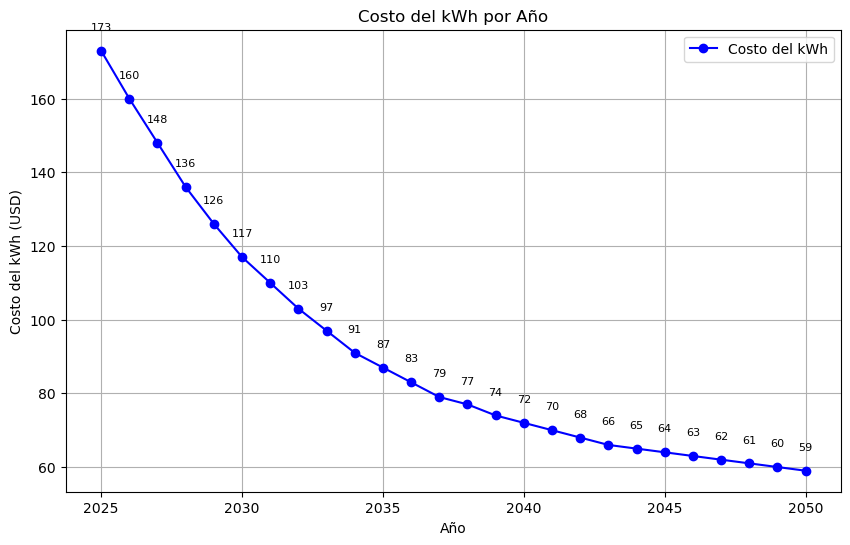

In [4]:
import matplotlib.pyplot as plt

# Ajustar los valores de los años y costos para que se vean mejor
años = list(costo_kwh.keys())
costos = [round(costo) for costo in costo_kwh.values()]  # Redondear los costos para quitar los decimales

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(años, costos, marker='o', linestyle='-', color='blue', label='Costo del kWh')

# Configurar el gráfico
plt.title('Costo del kWh por Año')
plt.xlabel('Año')
plt.ylabel('Costo del kWh (USD)')
plt.grid(True)
plt.legend()

# Añadir los valores de cada punto en la gráfica con mayor separación
for año, costo in zip(años, costos):
    plt.text(año, costo + 5, f'{costo}', fontsize=8, ha='center', va='bottom')  # Ajustar la posición del texto

plt.show()


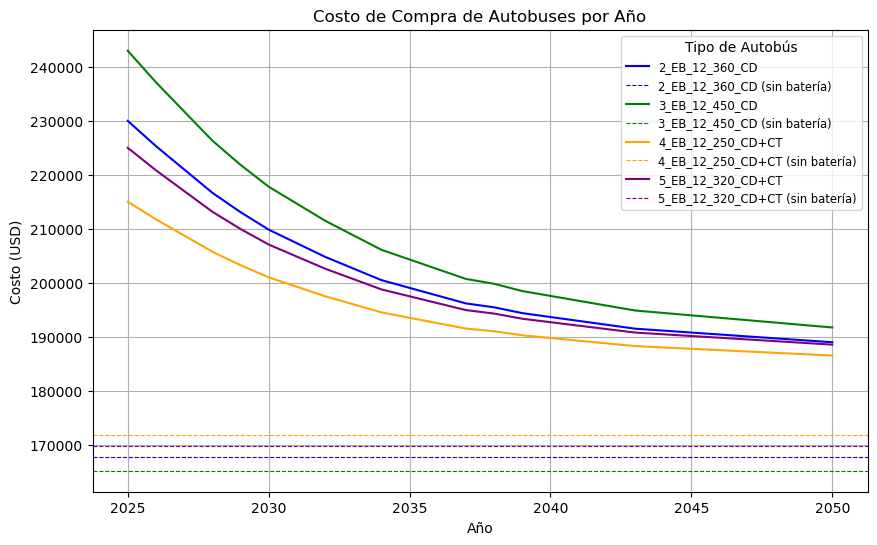

In [5]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Crear un diccionario para organizar los datos por tipo de autobús
costos_por_tipo = {}
for (k, t), costo in f.items():
    if k not in costos_por_tipo:
        costos_por_tipo[k] = {}
    costos_por_tipo[k][t] = costo

# Crear el gráfico
plt.figure(figsize=(10, 6))
# Definir una lista de colores personalizados o usar el colormap por defecto
custom_colors = ['red', 'blue', 'green', 'orange', 'purple']  # Puedes personalizar esta lista
colors = lambda idx: custom_colors[idx % len(custom_colors)]  # Asignar colores de la lista
for idx, (k, costos) in enumerate(costos_por_tipo.items()):
    if 'Diesel' not in k:
        años = sorted(costos.keys())
        valores = [costos[año] for año in años]
        color = colors(idx)  # Asignar un color único por tipo de autobús
        plt.plot(años, valores, label=k, color=color)
        # Añadir línea horizontal para el costo sin batería con el mismo color
        plt.axhline(y=cost_bus_sin_bat[k], linestyle='--', linewidth=0.8, label=f'{k} (sin batería)', color=color)

# Configurar el gráfico
plt.title('Costo de Compra de Autobuses por Año')
plt.xlabel('Año')
plt.ylabel('Costo (USD)')
plt.legend(title='Tipo de Autobús', loc='upper right', fontsize='small')
plt.grid(True)
plt.show()

In [6]:
sol_CB = {}
mo,x,y,z,w,u,v,b,u_tilde,v_tilde,w_diesel,w_energia,sol_salida = Transicion_flota_modelo(L,CT,T,K,J_K,J_K_tilde,K_E,K_R,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,o_inv,o_techo,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,var_epsilon,c_tilde,efic_bus,DA,epsilon,rho_N,sol_CB,params_exp)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-19
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-9700K CPU @ 3.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
MIPGap  0

Optimize a model with 22518 rows, 22256 columns and 111172 nonzeros
Model fingerprint: 0x8cdf2ea5
Variable types: 78 continuous, 22178 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-02, 1e+06]
  Objective range  [7e-02, 8e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+07]
Presolve removed 19034 rows and 8028 columns
Presolve time: 0.05s
Presolved: 3484 rows, 14228 columns, 35556 nonzeros
Variable types: 0 continuous, 14228 integer (72 binary)

Root relaxation: objective 4.336222e+07, 19370 iterations, 0.33 seconds 

In [7]:
from modulo_exportacion import exportar_solucion
informacion = {}

info_exportar = exportar_solucion(x,z,y,u,u_tilde,v,v_tilde,w,b,K,T,J_K,CT,R,f,p,o,F,g,mo,kappa,alpha,beta,num_per,p_tilde,K_E,J_K_tilde,t_F,s,mc,var_epsilon,Theta,Theta_tilde,L,params_exp)
informacion['Escenario 0'] = info_exportar


c:\Users\PC01\Documents\tesis_master_opti\modulo_exportacion.py:96: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  j.to_excel(writer, i)


In [8]:
# Convertir variables enteras a continuas (sólo para el análisis de sensibilidad)
from gurobipy import GRB

for var in mo.getVars():
    var.VType = GRB.CONTINUOUS
mo.update()
mo.optimize()


Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-9700K CPU @ 3.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
MIPGap  0

Optimize a model with 22518 rows, 22256 columns and 111172 nonzeros
Model fingerprint: 0x6f946b5a
Coefficient statistics:
  Matrix range     [5e-02, 1e+06]
  Objective range  [7e-02, 8e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+07]
Presolve removed 8128 rows and 8074 columns
Presolve time: 0.04s
Presolved: 14390 rows, 14182 columns, 70671 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.03s

Barrier statistics:
 AA' NZ     : 1.258e+05
 Factor NZ  : 3.133e+05 (roughly 14 MB of memory)
 Factor Ops : 1.561e+07 (less than 1 second per iteration)
 Threads    : 6

                  Objective                Residual
Ite

In [9]:
# imprimir intervalo permisible para las variables w_diesel,w_energia
for diccionario in [w_diesel, w_energia]:
    if params_exp['sensi_combus'][1]:
        for t,var in diccionario.items():
            print(f"{var.VarName}: SAObjLow = {var.SAObjLow} | Coef Ob = {var.Obj} | SAObjUp = {var.SAObjUp}")
    else:
        print(f"{diccionario.VarName}: SAObjLow = {diccionario  .SAObjLow} | Coef Ob = {diccionario   .Obj} | SAObjUp = {diccionario .SAObjUp}")

w_diesel[2025]: SAObjLow = 0.42069036435469714 | Coef Ob = 0.44 | SAObjUp = 0.445554962725794
w_diesel[2026]: SAObjLow = 0.4194286982204262 | Coef Ob = 0.44 | SAObjUp = 0.44257352537143807
w_diesel[2027]: SAObjLow = 0.4243488422552449 | Coef Ob = 0.44 | SAObjUp = 0.4549346866227412
w_diesel[2028]: SAObjLow = 0.439363428985478 | Coef Ob = 0.44 | SAObjUp = 0.4423735792255611
w_diesel[2029]: SAObjLow = 0.4398434221069282 | Coef Ob = 0.44 | SAObjUp = 0.4401328727349438
w_diesel[2030]: SAObjLow = 0.43610766636003095 | Coef Ob = 0.44 | SAObjUp = 0.4470024924999197
w_diesel[2031]: SAObjLow = 0.4388864236358465 | Coef Ob = 0.44 | SAObjUp = 0.4417328485366437
w_diesel[2032]: SAObjLow = 0.43852491809029687 | Coef Ob = 0.44 | SAObjUp = 0.4720414825727708
w_diesel[2033]: SAObjLow = 0.4384806656330058 | Coef Ob = 0.44 | SAObjUp = 0.44013163083946405
w_diesel[2034]: SAObjLow = 0.4369454686777852 | Coef Ob = 0.44 | SAObjUp = 0.4420820150685586
w_diesel[2035]: SAObjLow = 0.4112962708704163 | Coef Ob =

In [10]:
# imprimir intervalo permisible para las variables w_diesel,w_energia
nombre = ['Diesel','Energia']
for id,diccionario in enumerate([w_diesel, w_energia]):
    if params_exp['sensi_combus'][1]:
        minimo_low = min(var.SAObjLow for var in diccionario.values())
        minimo_up = min(var.SAObjUp for var in diccionario.values())
        maximo_low = max(var.SAObjLow for var in diccionario.values())
        maximo_up = max(var.SAObjUp for var in diccionario.values())
        print(f"Intervalo permisible para {nombre[id]}: [{minimo_low}, SAObjlow,  {maximo_low}] y [{minimo_up}, SAObjUp, {maximo_up}]")
        for t,var in diccionario.items():
            print(f"{var.VarName}: SAObjLow = {var.SAObjLow} | Coef Ob = {var.Obj} | SAObjUp = {var.SAObjUp}")
    else:
        print(f"{diccionario.VarName}: SAObjLow = {diccionario  .SAObjLow} | Coef Ob = {diccionario   .Obj} | SAObjUp = {diccionario .SAObjUp}")

Intervalo permisible para Diesel: [-0.045587840143335834, SAObjlow,  0.4398434221069282] y [0.44013163083946405, SAObjUp, 6.749051796026647]
w_diesel[2025]: SAObjLow = 0.42069036435469714 | Coef Ob = 0.44 | SAObjUp = 0.445554962725794
w_diesel[2026]: SAObjLow = 0.4194286982204262 | Coef Ob = 0.44 | SAObjUp = 0.44257352537143807
w_diesel[2027]: SAObjLow = 0.4243488422552449 | Coef Ob = 0.44 | SAObjUp = 0.4549346866227412
w_diesel[2028]: SAObjLow = 0.439363428985478 | Coef Ob = 0.44 | SAObjUp = 0.4423735792255611
w_diesel[2029]: SAObjLow = 0.4398434221069282 | Coef Ob = 0.44 | SAObjUp = 0.4401328727349438
w_diesel[2030]: SAObjLow = 0.43610766636003095 | Coef Ob = 0.44 | SAObjUp = 0.4470024924999197
w_diesel[2031]: SAObjLow = 0.4388864236358465 | Coef Ob = 0.44 | SAObjUp = 0.4417328485366437
w_diesel[2032]: SAObjLow = 0.43852491809029687 | Coef Ob = 0.44 | SAObjUp = 0.4720414825727708
w_diesel[2033]: SAObjLow = 0.4384806656330058 | Coef Ob = 0.44 | SAObjUp = 0.44013163083946405
w_diesel[2

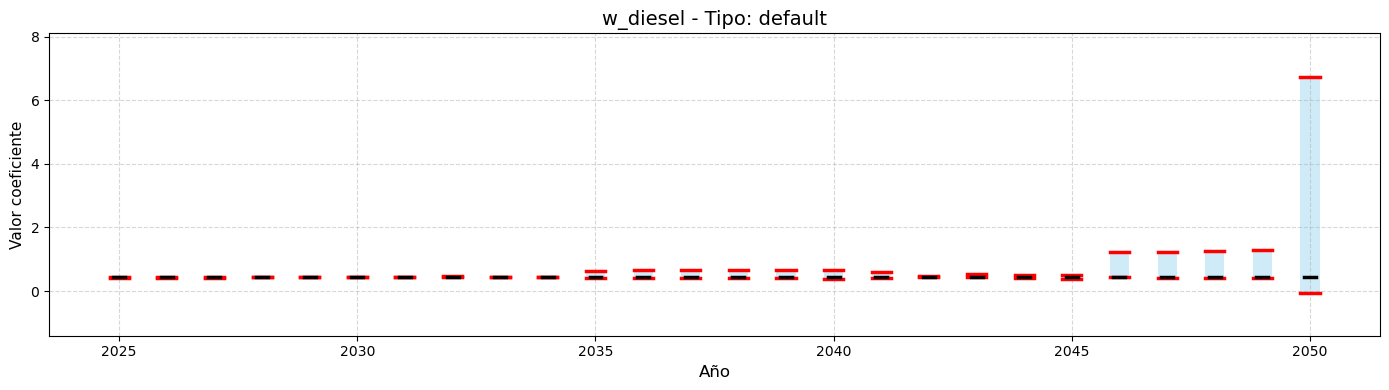

In [9]:
w_diesel_rango = graficar_sensibilidad_variable_v14(mo, w_diesel, 'w_diesel', eje_tiempo_idx=1)

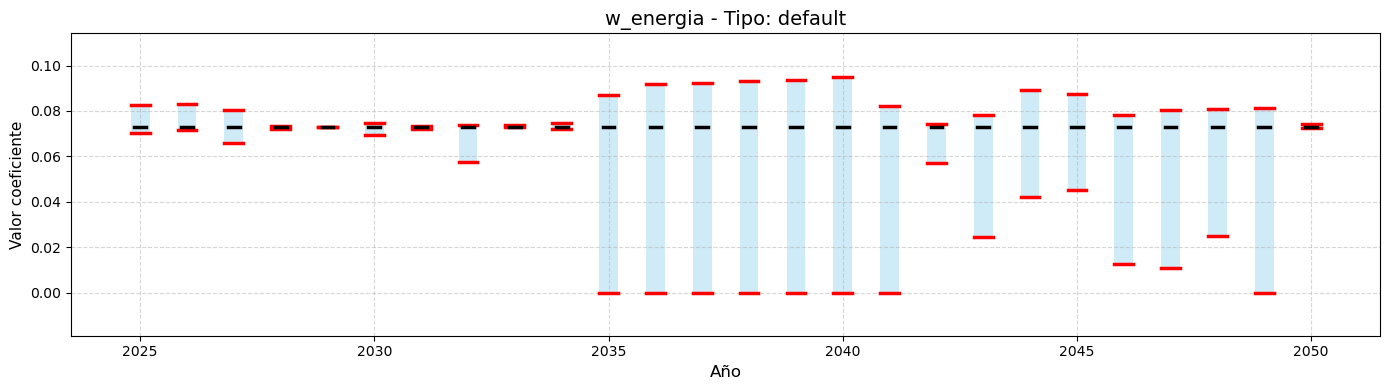

In [10]:
w_energia_rango = graficar_sensibilidad_variable_v14(mo, w_energia, 'w_energia', eje_tiempo_idx=1)

In [11]:
presupuesto = mo.getConstrByName('R-19_')
print(f"Presupuesto: {presupuesto.RHS} | Dual: {presupuesto.Pi} | SAObjLow: {presupuesto.SARHSLow} | SAObjUp: {presupuesto.SARHSUp} | Slack: {presupuesto.Slack}")

Presupuesto: 25000000.0 | Dual: 0.0 | SAObjLow: 23192830.0 | SAObjUp: inf | Slack: 1807169.999999999


In [ ]:
25000000 - 1807169.999999999 #

In [ ]:
mo.ObjVal
# minimizar el b para saber el presupuesto minimo para la transición
# que pasa con el b en minimo o % por arriba y por abajo

# primera opt min sum b llevando a valor presente y mover la restricción
# segunda opt min normal : b = [al del paso anterior], en restricicones y mover el %

# como afecta fijar el presupuesto minimo o movido en un % y ver como afecta el costo total en el largo plazo

In [ ]:
# podemos poner hitos
# * saber cuando ya está electrificada toda la flota o la mitad (varia de acuerdo a los costos)
# pintar dependiendo del año en que se electrficica, graficos de calor
# * con lo de las emisiones
# * en el modelo correr sin las metas de electrificación (netamente económico)

# 3 mapas de calor
# diesel energia color es el numero de años completar la elec flota
# diesel energia color es el numero de años 50% completar la elec flota 
# repetir los anteriores limitando las emisiones : sin limite, como actualmente está y relajar en 50% la medida


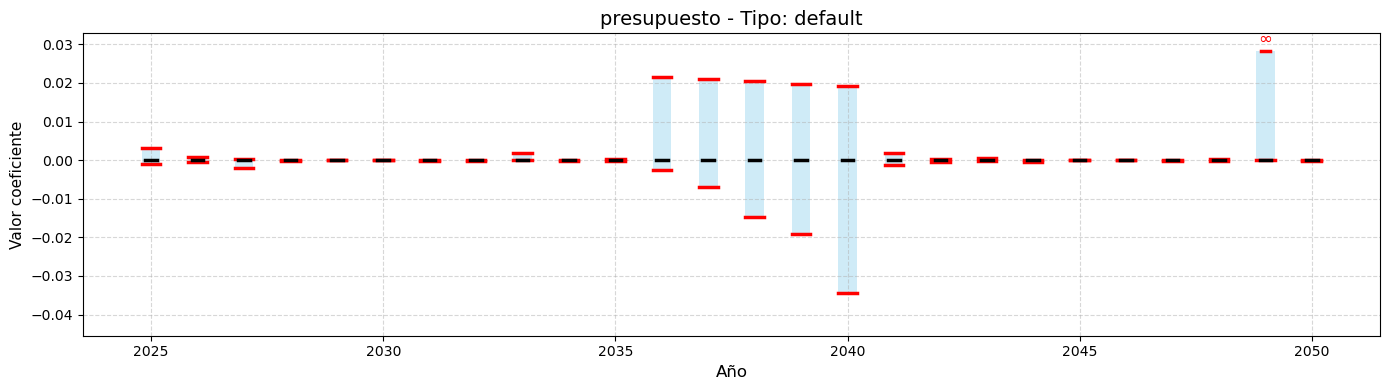

In [12]:
presupuesto = graficar_sensibilidad_variable_v14(mo, b, 'presupuesto', eje_tiempo_idx=1)


In [13]:
def int_costo_kwh(a,t,k,beta,cost_bus_sin_bat,K_E,T):
    trans_T = {j: i for i,j in enumerate(T)}
    """
    Función para calcular el costo del kWh en función de los parámetros de entrada.
    """
    # Calcular el costo del kWh
    if k in K_E:
        costo_kwh = ( ( a / ( beta**( (trans_T[t]+1) -1)  ) ) - cost_bus_sin_bat[k] ) / tam_bat(k,K_E)
    else:
        costo_kwh = a
    return costo_kwh

In [ ]:
x_rango = graficar_sensibilidad_variable_v14(mo, x, 'x', eje_tiempo_idx=1)
x_rango2 = {(k,t): [ (int_costo_kwh(j[0][0],t,k,beta,cost_bus_sin_bat,K_E,T),int_costo_kwh(j[0][1],t,k,beta,cost_bus_sin_bat,K_E,T) ) , int_costo_kwh(j[1],t,k,beta,cost_bus_sin_bat,K_E,T) ] for (k,t),j in x_rango.items()}

In [ ]:
graficar_sensibilidad_costo_kwh(x_rango2, 'Costo del kWh', eje_tiempo_idx=1,porcen = True)

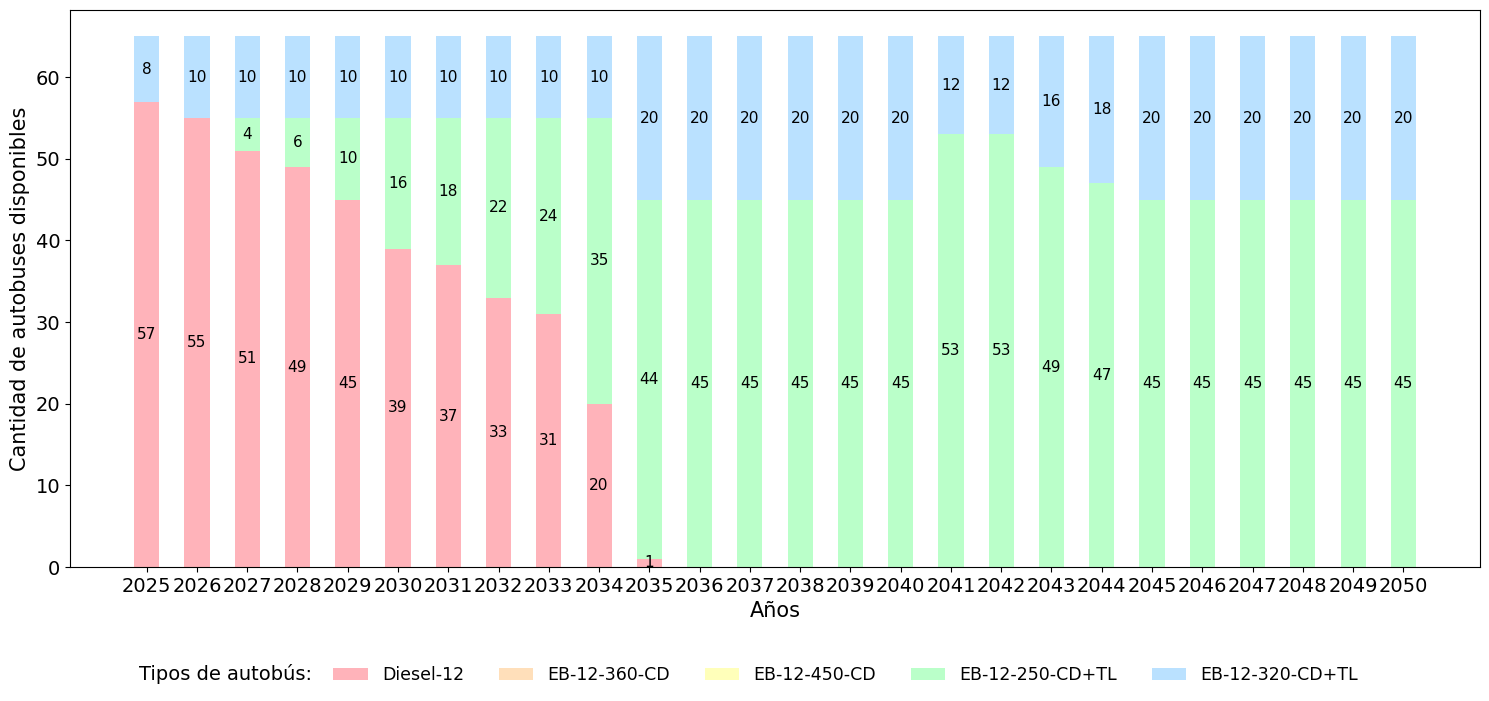

In [14]:
graficar_un_escenario(informacion, 'Autobuses Disponibles', 'Escenario 0', list(range(2025,2051)))

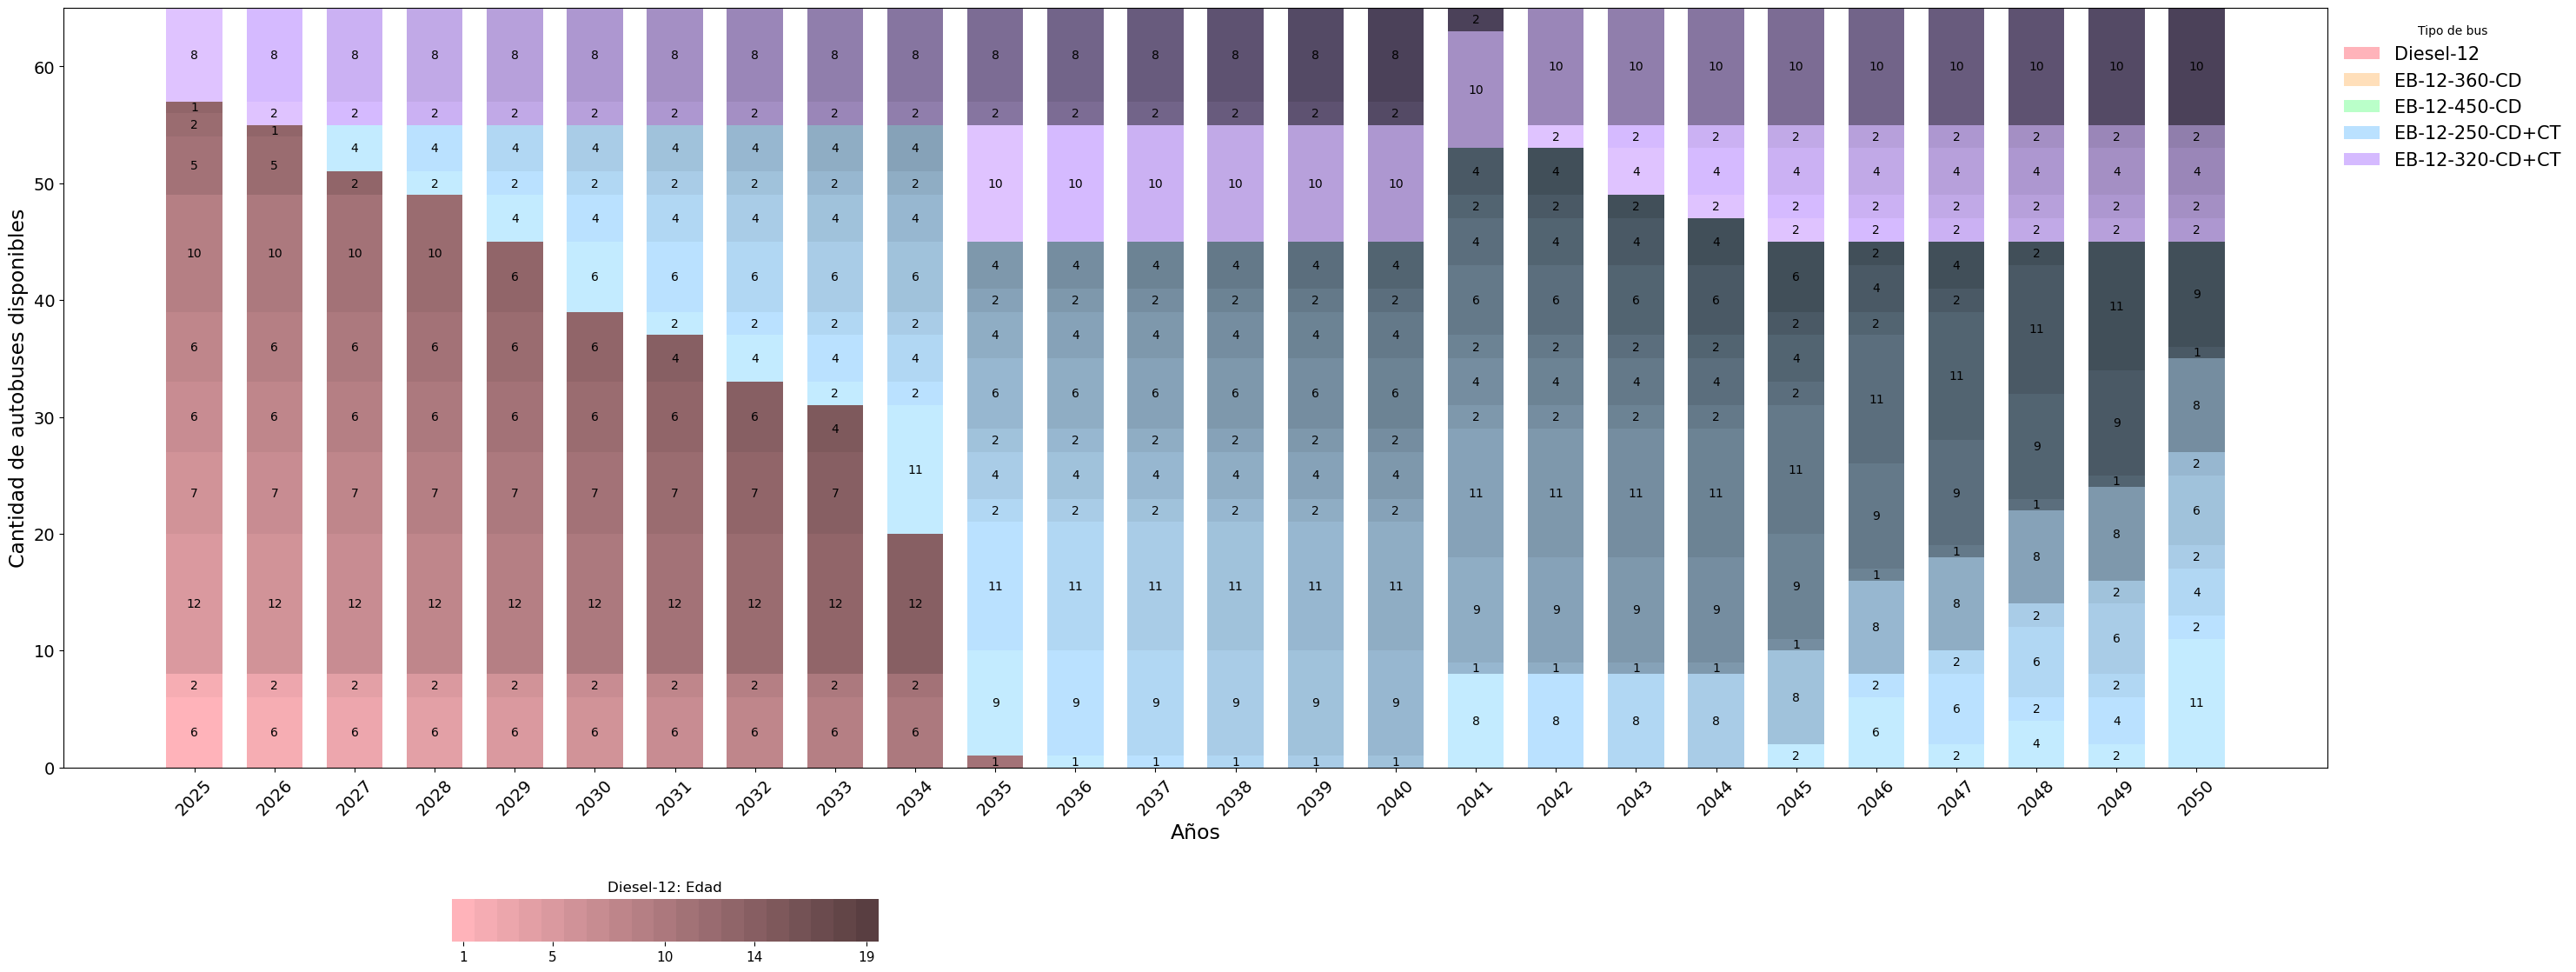

In [15]:
graficar_un_escenario_edades(informacion, 'Autobuses Disponibles', 'Escenario 0', list(range(2025,2051)))

In [ ]:
graficar_un_escenario_cargadores_contenedores(informacion, 'Cargadores Disponibles', 'Contenedores Disponibles', 'Escenario 0', list(range(2025,2051)))

In [ ]:
'''
informacion = {}

info_exportar = exportar_solucion(x,z,y,u,u_tilde,v,v_tilde,w,b,K,T,J_K,CT,R,f,p,o,F,g,mo,kappa,alpha,beta,num_per,p_tilde,K_E,J_K_tilde,t_F,s,mc,var_epsilon,Theta,Theta_tilde,L,params_exp)
informacion['Escenario {}'.format(i)] = info_exportar
del L,CT,T,K,J_K,J_K_tilde,K_E,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,Theta_tilde,var_epsilon,c_tilde
del mo,x,y,z,w,u,v,b,u_tilde,v_tilde,sol_salida
del info_exportar, params_exp
'''

In [ ]:
'''
escenarios_0_10_11 = {i:j for i,j in informacion.items() if int(i.split(' ')[1]) in [0,10,11]}
escenarios_sin_10_11 = {i:j for i,j in informacion.items() if int(i.split(' ')[1]) not in [10,11]}
graficar_un_escenario(informacion, 'Autobuses Disponibles', 'Escenario 0', [2025,2026,2027,2028,2029])
graficar_un_escenario_cargadores_contenedores(informacion, 'Cargadores Disponibles', 'Contenedores Disponibles', 'Escenario 0', [2025,2026,2027,2028,2029])
graficar_autobuses_por_tipo_varios_anios_subplots(escenarios_sin_10_11, 'Autobuses Disponibles', [2025,2026,2027,2028,2029])
graficar_autobuses_por_tipo_varios_anios_subplots(escenarios_0_10_11, 'Autobuses Disponibles', list(range(2025,2035)))
graficar_inversion_acumulada_por_escenario(escenarios_0_10_11, 'Inversion')
graficar_inversion_acumulada_por_escenario(escenarios_sin_10_11, 'Inversion')
graficar_cargadores_y_contenedores_por_tipo_varios_anios_subplots(escenarios_sin_10_11, 'Cargadores Disponibles', 'Contenedores Disponibles', [2025, 2026, 2027, 2028, 2029])
graficar_cargadores_y_contenedores_por_tipo_varios_anios_subplots(escenarios_0_10_11, 'Cargadores Disponibles', 'Contenedores Disponibles', list(range(2025,2035)))
graficar_costos_por_tipo(informacion, 'Resumen')
graficar_emisiones_por_contaminante(escenarios_sin_10_11, 'Emisiones', 'SO2')
graficar_emisiones_por_contaminante(escenarios_sin_10_11, 'Emisiones', 'PM25')
graficar_emisiones_por_contaminante(escenarios_sin_10_11, 'Emisiones', 'NOX')
graficar_asignacion_autobuses_por_ruta(informacion, 'Autobuses electricos por ruta')
''';

In [ ]:
graficar_emisiones_por_contaminante(informacion, 'Emisiones', 'SO2')

In [ ]:
graficar_inversion_acumulada_por_escenario(informacion, 'Inversion')

In [ ]:
graficar_costos_por_tipo(informacion, 'Resumen')

In [ ]:
model = mo

In [ ]:

# Maximum number of scenarios to be considered
maxScenarios = 100

if model.IsMIP == 0:
    print("Model is not a MIP")

# Solve model
model.optimize()

if model.Status != GRB.OPTIMAL:
    print(f"Optimization ended with status {model.Status}")
    sys.exit(0)

# Store the optimal solution
origObjVal = model.ObjVal
for v in model.getVars():
    v._origX = v.X


scenarios = 0

# Count number of unfixed, binary variables in model. For each we create a
# scenario.
for v in model.getVars():
    if v.LB == 0.0 and v.UB == 1.0 and v.VType in (GRB.BINARY, GRB.INTEGER):
        scenarios += 1

        if scenarios >= maxScenarios:
            break


# Set the number of scenarios in the model
model.NumScenarios = scenarios
scenarios = 0

print(f"###  construct multi-scenario model with {scenarios} scenarios")

# Create a (single) scenario model by iterating through unfixed binary
# variables in the model and create for each of these variables a scenario
# by fixing the variable to 1-X, where X is its value in the computed
# optimal solution
for v in model.getVars():
    if (
        v.LB == 0.0
        and v.UB == 1.0
        and v.VType in (GRB.BINARY, GRB.INTEGER)
        and scenarios < maxScenarios
    ):
        # Set ScenarioNumber parameter to select the corresponding scenario
        # for adjustments
        model.Params.ScenarioNumber = scenarios

        # Set variable to 1-X, where X is its value in the optimal solution
        if v._origX < 0.5:
            v.ScenNLB = 1.0
        else:
            v.ScenNUB = 0.0

        scenarios += 1

    else:
        # Add MIP start for all other variables using the optimal solution
        # of the base model
        v.Start = v._origX


# Solve multi-scenario model
model.optimize()


# In case we solved the scenario model to optimality capture the
# sensitivity information
if model.Status == GRB.OPTIMAL:
    modelSense = model.ModelSense
    scenarios = 0

    # Capture sensitivity information from each scenario
    for v in model.getVars():
        if v.LB == 0.0 and v.UB == 1.0 and v.VType in (GRB.BINARY, GRB.INTEGER):
            # Set scenario parameter to collect the objective value of the
            # corresponding scenario
            model.Params.ScenarioNumber = scenarios

            # Collect objective value and bound for the scenario
            scenarioObjVal = model.ScenNObjVal
            scenarioObjBound = model.ScenNObjBound

            # Check if we found a feasible solution for this scenario
            if modelSense * scenarioObjVal >= GRB.INFINITY:
                # Check if the scenario is infeasible
                if modelSense * scenarioObjBound >= GRB.INFINITY:
                    print(
                        f"Objective sensitivity for variable {v.VarName} is infeasible"
                    )
                else:
                    print(
                        f"Objective sensitivity for variable {v.VarName} is unknown (no solution available)"
                    )
            else:
                # Scenario is feasible and a solution is available
                print(
                    f"Objective sensitivity for variable {v.VarName} is {modelSense * (scenarioObjVal - origObjVal):g}"
                )

            scenarios += 1

            if scenarios >= maxScenarios:
                break